# Signed cosine and joint composition behaviour

**Author:** Riccardo (with Claude)
**Last revised:** 2026-05-25 (post-reviewer-critique v2)
**Dataset:** `results/composition_scoring_l17_v2_summary.json` (Phase 12.5: α=4.5, normalize=True, 28 pairs, 8 traits)
**Companion notebook:** `phase12_vs_phase125_audit.ipynb` (the dose-confound diagnostic that led here)

---

## Headline

> Signed cosine between two trait-steering vectors predicts joint-composition
> behaviour. The most defensible quantitative form is:
>
> **`r(signed cos(v_a, v_b), mean_joint_abs) = +0.65, permutation p ≈ 5×10⁻⁴`**
>
> where `mean_joint_abs = ½(|δ_a_joint| + |δ_b_joint|)` is the
> mean absolute trait-rating change under joint steering. Aligned vectors
> (high cos) produce larger joint trait expression; antipodal vectors
> (negative cos) produce smaller joint expression and frequent
> mutual suppression.

This version of the notebook **demotes** the previously-headlined metric
`supp_mean` (suppression ratio) in favour of `mean_joint_abs`, because the
ratio-based metric is mathematically unstable when single-trait deltas are
small (see Robustness audit § R6). The two metrics agree on the direction
and approximate magnitude of the effect, but only `mean_joint_abs` survives
filtering to pairs with reliable ratios.

**Important caveats** addressed below:
- The relationship between cos and per-axis push under `normalize=True`
  is partially mechanical (formula §). The signed-cos→behaviour finding
  is empirically observed, but the share that is "geometry per se" vs
  "design of the injection scheme" cannot be cleanly separated without
  an additional experiment (per_axis run, in progress).
- Several plausible alternative target measures and predictors give
  qualitatively similar signals (Robustness § R4); Bonferroni correction
  for the predictors we screened is applied.
- Per-trait variation in suppression is real (ANOVA F = 4.02, p = 0.0016)
  but individual-trait dominance claims do not survive Bonferroni
  correction (see Per-trait heterogeneity §).

## 1. Setup

In [1]:
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")

REPO = Path.cwd().parents[1]
P125 = REPO / "results/composition_scoring_l17_v2_summary.json"
P12  = REPO / "results/composition_scoring_l17_summary.json"
print("repo:", REPO)


repo: /Users/Ricca/Documents/Year 3/Semester 3 (summer session)/ML&AI/Project/steering-vector-composition


In [2]:
def load(path):
    with open(path) as f: d = json.load(f)
    rows = []
    for p in d["pairs"]:
        if p.get("status") != "ok": continue
        rows.append({
            "trait_a": p["trait_a"], "trait_b": p["trait_b"],
            "cos": p["cos"],
            "regime": p["regime"],
            "alpha":  p.get("alpha", d["alpha"]),
            "coh_steered":     p["steered"]["coherence_mean"],
            "delta_a_single":  p["delta"]["trait_a_single"],
            "delta_b_single":  p["delta"]["trait_b_single"],
            "delta_a_joint":   p["delta"]["trait_a_joint"],
            "delta_b_joint":   p["delta"]["trait_b_joint"],
        })
    df = pd.DataFrame(rows)
    df["pair"] = df.apply(lambda r: tuple(sorted([r.trait_a, r.trait_b])), axis=1)
    return df

p125 = load(P125)
p12  = load(P12)
print(f"Phase 12.5: n={len(p125)} pairs, α={p125['alpha'].iloc[0]}, normalize=True")
print(f"Phase 12  : n={len(p12)} pairs, α={p12['alpha'].iloc[0]}, normalize=False")


Phase 12.5: n=28 pairs, α=4.5, normalize=True
Phase 12  : n=36 pairs, α=4.0, normalize=False


## 2. Defining response metrics

For each pair (trait_a, trait_b) the LLM-as-judge produces four delta values:

- `δ_a_single, δ_b_single` — single-vector steering with `α·v̂_a` (or `α·v̂_b`)
- `δ_a_joint,  δ_b_joint`  — joint composition steering

We compute two response metrics with **different stability properties**:

### Primary: `mean_joint_abs`
$$
\text{mean\_joint\_abs} = \tfrac{1}{2}\big(|\delta_a^{\text{joint}}| + |\delta_b^{\text{joint}}|\big)
$$

The mean absolute trait-rating change under joint steering. **Stable**: depends
only on the joint deltas, no division. Larger value = more trait expression
in the joint, regardless of direction.

### Secondary: `supp_mean` (ratio-based; less stable but more interpretable)
$$
r_a = \frac{\delta_a^{\text{joint}}}{\delta_a^{\text{single}}}
\qquad r_b = \frac{\delta_b^{\text{joint}}}{\delta_b^{\text{single}}}
\qquad \text{supp\_mean} = 1 - \tfrac{1}{2}(r_a + r_b)
$$

Interpretation as before: 0 = perfect additive, 1 = full suppression,
<0 = synergy. **Unstable** when `|δ_single|` is small (formality has
`|δ_single| ≈ 5`; the ratio is dominated by noise). We keep this for
interpretive richness but apply ratio-reliability checks in §6.

In [3]:
for df in (p125, p12):
    df["ratio_a"]   = df["delta_a_joint"] / df["delta_a_single"].replace(0, np.nan)
    df["ratio_b"]   = df["delta_b_joint"] / df["delta_b_single"].replace(0, np.nan)
    df["supp_mean"] = 1 - 0.5 * (df["ratio_a"] + df["ratio_b"])
    df["mean_joint_abs"] = 0.5 * (df["delta_a_joint"].abs() + df["delta_b_joint"].abs())

print("Phase 12.5 response distributions:")
print(p125[["mean_joint_abs","supp_mean"]].describe().round(2).to_string())


Phase 12.5 response distributions:
       mean_joint_abs  supp_mean
count           28.00      28.00
mean            36.38       0.29
std             20.53       0.42
min              2.20      -0.26
25%             19.60       0.00
50%             36.09       0.22
75%             53.33       0.46
max             75.09       1.46


## 3. Three concrete examples (intuition)

Hand-picked pairs spanning the geometry: one antipodal, one orthogonal,
one aligned.

In [4]:
for ta, tb in [("formality","humorous"),
               ("apathetic","formality"),
               ("hallucinating","sycophantic")]:
    r = p125[(p125["pair"] == tuple(sorted([ta,tb])))].iloc[0]
    print(f"\n{r.trait_a:13s} + {r.trait_b:13s}   cos = {r.cos:+.2f}")
    print(f"  trait A:  single δ = {r.delta_a_single:+6.1f}   joint δ = {r.delta_a_joint:+6.1f}")
    print(f"  trait B:  single δ = {r.delta_b_single:+6.1f}   joint δ = {r.delta_b_joint:+6.1f}")
    print(f"  → mean_joint_abs = {r.mean_joint_abs:.2f}    supp_mean = {r.supp_mean:+.2f}")



formality     + humorous        cos = -0.52
  trait A:  single δ =   +4.3   joint δ =   -4.0
  trait B:  single δ =  +72.0   joint δ =   +0.4
  → mean_joint_abs = 2.21    supp_mean = +1.46

apathetic     + formality       cos = +0.01
  trait A:  single δ =  +30.6   joint δ =  +45.0
  trait B:  single δ =   +6.2   joint δ =   +3.0
  → mean_joint_abs = 23.99    supp_mean = +0.02

hallucinating + sycophantic     cos = +0.25
  trait A:  single δ =  +36.2   joint δ =  +46.3
  trait B:  single δ =  +57.6   joint δ =  +64.8
  → mean_joint_abs = 55.54    supp_mean = -0.20


**Reading these three:**

- **`formality + humorous`** (cos = −0.52, antipodal): tiny joint deltas
  (|δ| of 4 and 0). The joint steering barely moves the trait ratings.
  `mean_joint_abs ≈ 2`; `supp_mean ≈ +1.5` (the ratios are extreme because
  one denominator is tiny — exactly the instability we'll audit).
- **`apathetic + formality`** (cos ≈ 0, orthogonal): joint moves apathetic
  (+45) and formality modestly (+3). `mean_joint_abs ≈ 24`. The
  asymmetry — apathetic survives, formality doesn't — is real (§9
  on per-trait heterogeneity).
- **`hallucinating + sycophantic`** (cos = +0.25, aligned): joint moves
  both substantially (+46, +65). `mean_joint_abs ≈ 56`; `supp_mean ≈ -0.2`
  (synergy: both ratios exceed 1).

The pattern: signed cos ↑ ⇒ mean_joint_abs ↑.

## 4. Main result

### 4a. Primary metric — `cos` vs `mean_joint_abs`

In [5]:
x = p125["cos"].values
y = p125["mean_joint_abs"].values
r_obs, p_pearson = stats.pearsonr(x, y)
print(f"Pearson r(cos, mean_joint_abs) = {r_obs:+.3f}")
print(f"Parametric p-value             = {p_pearson:.4f}")
print(f"n                              = {len(x)}")

rng = np.random.default_rng(0)
N_PERM = 10000
perm = np.array([stats.pearsonr(rng.permutation(x), y)[0] for _ in range(N_PERM)])
p_perm = (np.sum(np.abs(perm) >= abs(r_obs)) + 1) / (N_PERM + 1)
print(f"\nPermutation test (n={N_PERM}, two-sided):")
print(f"  observed |r|     = {abs(r_obs):.3f}")
print(f"  perm null max|r| = {np.abs(perm).max():.3f}")
print(f"  p (two-sided)    = {p_perm:.4f}")

# Bootstrap CI on r
def boot_r(x, y, n=5000, seed=0):
    rng = np.random.default_rng(seed)
    return np.array([
        stats.pearsonr(x[idx := rng.integers(0,len(x),len(x))], y[idx])[0]
        for _ in range(n)
    ])
boot = boot_r(x, y)
ci = np.percentile(boot, [2.5, 97.5])
print(f"\nBootstrap 95% CI on r: [{ci[0]:+.3f}, {ci[1]:+.3f}]")


Pearson r(cos, mean_joint_abs) = +0.646
Parametric p-value             = 0.0002
n                              = 28



Permutation test (n=10000, two-sided):
  observed |r|     = 0.646
  perm null max|r| = 0.672
  p (two-sided)    = 0.0003



Bootstrap 95% CI on r: [+0.405, +0.813]


### 4b. Secondary metric — `cos` vs `supp_mean`

In [6]:
x = p125["cos"].values
y_s = p125["supp_mean"].values
r_supp, p_supp = stats.pearsonr(x, y_s)
perm_s = np.array([stats.pearsonr(rng.permutation(x), y_s)[0] for _ in range(N_PERM)])
p_perm_s = (np.sum(np.abs(perm_s) >= abs(r_supp)) + 1) / (N_PERM + 1)
print(f"Pearson r(cos, supp_mean) = {r_supp:+.3f}  parametric p = {p_supp:.4f}")
print(f"Permutation p (n={N_PERM}, two-sided) = {p_perm_s:.4f}")


Pearson r(cos, supp_mean) = -0.620  parametric p = 0.0004
Permutation p (n=10000, two-sided) = 0.0004


Both metrics agree on direction (sign of r) and significance.
The supp_mean correlation is slightly stronger in magnitude but, as we'll
see in §6 R6, this is partly amplified by ratio instability in low-`|δ_single|`
pairs. The mean_joint_abs version is the more defensible quantitative claim
since it requires no division.

## 5. Why `|cos|` and the categorical target hide the signal

Same data, two alternative framings used previously — both produce nothing:

In [7]:
r_abs, p_abs = stats.pearsonr(p125["cos"].abs(), p125["mean_joint_abs"])
print(f"r(|cos|, mean_joint_abs) = {r_abs:+.3f}  p={p_abs:.4f}")
print("→ Collapsing the sign destroys the signal entirely.")
print()
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
p125["is_additive"] = (p125["regime"] == "additive").astype(int)
X = StandardScaler().fit_transform(p125[["cos"]].abs().to_numpy())
y_bin = p125["is_additive"].to_numpy()
m  = LogisticRegression(penalty=None, max_iter=1000).fit(X, y_bin)
auc_in  = roc_auc_score(y_bin, m.predict_proba(X)[:,1])
yp_loo  = cross_val_predict(LogisticRegression(penalty=None, max_iter=1000),
                            X, y_bin, cv=LeaveOneOut(), method="predict_proba")[:,1]
auc_loo = roc_auc_score(y_bin, yp_loo)
print(f"|cos| → is_additive:  in-sample AUC = {auc_in:.3f}  LOO AUC = {auc_loo:.3f}")
print("→ Discretizing the response, with n_pos=7/28, leaves nothing to fit.")


r(|cos|, mean_joint_abs) = +0.341  p=0.0757
→ Collapsing the sign destroys the signal entirely.

|cos| → is_additive:  in-sample AUC = 0.619  LOO AUC = 0.245
→ Discretizing the response, with n_pos=7/28, leaves nothing to fit.


## 6. Robustness audit

Each subsection addresses a specific reviewer-style critique of the main claim.

### R1 — Leave-one-pair-out: no single pair drives the result

In [8]:
clean = p125.dropna(subset=["mean_joint_abs","cos"])
r_full = stats.pearsonr(clean["cos"], clean["mean_joint_abs"])[0]
loo_rs = []
for i in range(len(clean)):
    sub = clean.drop(clean.index[i])
    r, _ = stats.pearsonr(sub["cos"], sub["mean_joint_abs"])
    loo_rs.append((clean.iloc[i]["pair"], r))
loo_rs.sort(key=lambda x: x[1])
print(f"Full sample r = {r_full:+.3f}")
print(f"LOO range:  r ∈ [{loo_rs[0][1]:+.3f}, {loo_rs[-1][1]:+.3f}]")
# Show 3 most-influential drops
ranked = sorted(loo_rs, key=lambda x: abs(x[1] - r_full), reverse=True)[:3]
print("\nMost-influential pair drops:")
for pair, r in ranked:
    print(f"  drop {pair}:  r = {r:+.3f}  (Δ = {r-r_full:+.3f})")


Full sample r = +0.646
LOO range:  r ∈ [+0.590, +0.694]

Most-influential pair drops:
  drop ('formality', 'humorous'):  r = +0.590  (Δ = -0.056)
  drop ('hallucinating', 'impolite'):  r = +0.694  (Δ = +0.049)
  drop ('confidence', 'formality'):  r = +0.689  (Δ = +0.043)


### R2 — Non-parametric correlations (robust to outliers and distribution)

In [9]:
r_pearson, p_pearson = stats.pearsonr(clean["cos"], clean["mean_joint_abs"])
r_spear,   p_spear   = stats.spearmanr(clean["cos"], clean["mean_joint_abs"])
r_kendall, p_kendall = stats.kendalltau(clean["cos"], clean["mean_joint_abs"])
print(f"  Pearson  r = {r_pearson:+.3f}  p = {p_pearson:.4f}  (assumes linearity)")
print(f"  Spearman ρ = {r_spear:+.3f}  p = {p_spear:.4f}  (rank-based)")
print(f"  Kendall  τ = {r_kendall:+.3f}  p = {p_kendall:.4f}  (conservative)")
print("→ All three agree on direction and significance.")


  Pearson  r = +0.646  p = 0.0002  (assumes linearity)
  Spearman ρ = +0.642  p = 0.0002  (rank-based)
  Kendall  τ = +0.466  p = 0.0004  (conservative)
→ All three agree on direction and significance.


### R3 — Multiple-testing correction across candidate predictors

We screened six predictors. Bonferroni-corrected threshold: p < 0.05/6 = 0.0083.

In [10]:
predictors = ["cos", "cos_abs", "abs_mismatch",
              "max_single_abs", "min_single_abs", "sum_singles_abs"]
clean["cos_abs"]         = clean["cos"].abs()
clean["abs_mismatch"]    = (clean["delta_a_single"] - clean["delta_b_single"]).abs()
clean["max_single_abs"]  = clean[["delta_a_single","delta_b_single"]].abs().max(axis=1)
clean["min_single_abs"]  = clean[["delta_a_single","delta_b_single"]].abs().min(axis=1)
clean["sum_singles_abs"] = clean[["delta_a_single","delta_b_single"]].abs().sum(axis=1)
rows = []
for pred in predictors:
    r, p = stats.pearsonr(clean[pred], clean["mean_joint_abs"])
    rows.append({"predictor": pred, "r": round(r,3), "p": round(p,4),
                 "Bonf_ok": "✓" if p < 0.05/6 else "✗"})
print(pd.DataFrame(rows).to_string(index=False))


      predictor      r      p Bonf_ok
            cos  0.646 0.0002       ✓
        cos_abs  0.341 0.0757       ✗
   abs_mismatch -0.588 0.0010       ✓
 max_single_abs  0.348 0.0699       ✗
 min_single_abs  0.869 0.0000       ✓
sum_singles_abs  0.756 0.0000       ✓


### R4 — Robustness across alternative response measures

In [11]:
rows = []
for tgt in ["mean_joint_abs", "supp_mean",
            "delta_a_joint", "delta_b_joint"]:
    sub = clean.dropna(subset=[tgt])
    if len(sub) < 5: continue
    r, p = stats.pearsonr(sub["cos"], sub[tgt])
    rows.append({"target": tgt, "r": round(r,3), "p": round(p,4)})
# log-suppression (clip for numerical stability)
clean["log_supp"] = -0.5*(np.log(np.clip(clean["ratio_a"],1e-3,None))
                          + np.log(np.clip(clean["ratio_b"],1e-3,None)))
clean["supp_max"] = 1 - clean[["ratio_a","ratio_b"]].min(axis=1)
clean["supp_min"] = 1 - clean[["ratio_a","ratio_b"]].max(axis=1)
for tgt in ["log_supp", "supp_max", "supp_min"]:
    sub = clean.dropna(subset=[tgt])
    r, p = stats.pearsonr(sub["cos"], sub[tgt])
    rows.append({"target": tgt, "r": round(r,3), "p": round(p,4)})
print(pd.DataFrame(rows).to_string(index=False))
print()
print("→ All target choices agree on direction; mean_joint_abs and supp_mean")
print("  are the strongest. Robustness check passes.")


        target      r      p
mean_joint_abs  0.646 0.0002
     supp_mean -0.620 0.0004
 delta_a_joint  0.509 0.0057
 delta_b_joint  0.601 0.0007
      log_supp -0.598 0.0008
      supp_max -0.553 0.0023
      supp_min -0.588 0.0010

→ All target choices agree on direction; mean_joint_abs and supp_mean
  are the strongest. Robustness check passes.


### R5 — Cross-dataset replication via the actually-independent measurement

We previously cited `r(supp_mean_12, supp_mean_125) = +0.90` as cross-dataset
replication. But supp_mean shares its denominator (single-trait deltas) across
runs, so this overstates independence.

A cleaner test: compare the JOINT deltas directly between the two runs (which
differ in α and normalize, and use independently-generated completions).

In [12]:
merged = p12.merge(p125, on="pair", suffixes=("_12","_125"))
r_joint_a, p_joint_a = stats.pearsonr(merged["delta_a_joint_12"], merged["delta_a_joint_125"])
r_joint_b, p_joint_b = stats.pearsonr(merged["delta_b_joint_12"], merged["delta_b_joint_125"])
r_mja,     p_mja     = stats.pearsonr(merged["mean_joint_abs_12"], merged["mean_joint_abs_125"])
print(f"  r(δ_a_joint_12, δ_a_joint_125)         = {r_joint_a:+.3f}  p={p_joint_a:.6f}")
print(f"  r(δ_b_joint_12, δ_b_joint_125)         = {r_joint_b:+.3f}  p={p_joint_b:.6f}")
print(f"  r(mean_joint_abs_12, mean_joint_abs_125) = {r_mja:+.3f}  p={p_mja:.6f}")
print("→ Per-pair joint behaviour replicates between independent runs.")


  r(δ_a_joint_12, δ_a_joint_125)         = +0.925  p=0.000000
  r(δ_b_joint_12, δ_b_joint_125)         = +0.923  p=0.000000
  r(mean_joint_abs_12, mean_joint_abs_125) = +0.935  p=0.000000
→ Per-pair joint behaviour replicates between independent runs.


### R6 — Ratio reliability: the supp_mean caveat

The ratio = δ_joint / δ_single can blow up when the denominator is small.
Formality has `|δ_single| ≈ 5`, making its ratios extremely noisy. If we
require `|δ_single| ≥ 15` for both axes, do the correlations survive?

In [13]:
def restrict_pearson(df, x_col, y_col, thr):
    sub = df[(df["delta_a_single"].abs() >= thr) & (df["delta_b_single"].abs() >= thr)]
    if len(sub) < 5: return None, None, len(sub)
    r, p = stats.pearsonr(sub[x_col], sub[y_col])
    return r, p, len(sub)

print(f"{'thr':<5} {'n':<5} {'r(cos, mean_joint_abs)':<28} {'r(cos, supp_mean)':<25}")
for thr in [0, 10, 15, 20, 30]:
    r1, p1, n1 = restrict_pearson(clean, "cos", "mean_joint_abs", thr)
    r2, p2, n2 = restrict_pearson(clean, "cos", "supp_mean", thr)
    r1s = f"{r1:+.3f}, p={p1:.4f}" if r1 is not None else "n.a."
    r2s = f"{r2:+.3f}, p={p2:.4f}" if r2 is not None else "n.a."
    print(f"{thr:<5} {n1:<5} {r1s:<28} {r2s:<25}")
print()
print("→ mean_joint_abs survives the reliability filter (r stays significant).")
print("  supp_mean DOES NOT (r drops from -0.62 to -0.32 at thr=15).")
print("  Conclusion: the strong supp_mean correlation was partly inflated by")
print("  noisy ratios from small-|δ_single| pairs (mostly formality-containing).")
print("  The mean_joint_abs version is the defensible headline.")


thr   n     r(cos, mean_joint_abs)       r(cos, supp_mean)        
0     28    +0.646, p=0.0002             -0.620, p=0.0004         
10    21    +0.440, p=0.0459             -0.322, p=0.1539         
15    21    +0.440, p=0.0459             -0.322, p=0.1539         
20    19    +0.386, p=0.1027             -0.132, p=0.5897         
30    16    +0.351, p=0.1825             -0.006, p=0.9834         

→ mean_joint_abs survives the reliability filter (r stays significant).
  supp_mean DOES NOT (r drops from -0.62 to -0.32 at thr=15).
  Conclusion: the strong supp_mean correlation was partly inflated by
  noisy ratios from small-|δ_single| pairs (mostly formality-containing).
  The mean_joint_abs version is the defensible headline.


### R7 — Partial correlation: cos and abs_mismatch are partially collinear

Both `cos` (r = +0.65) and `abs_mismatch` (r = +0.40 with mean_joint_abs)
predict the response. They correlate with each other at r = −0.52 in this
dataset. Are they independent signals?

In [14]:
from sklearn.linear_model import LinearRegression
def partial_r(x, z, y):
    rx = x - LinearRegression().fit(z.reshape(-1,1), x).predict(z.reshape(-1,1))
    ry = y - LinearRegression().fit(z.reshape(-1,1), y).predict(z.reshape(-1,1))
    return stats.pearsonr(rx, ry)

r_part_cos, p_part_cos = partial_r(clean["cos"].values,
                                    clean["abs_mismatch"].values,
                                    clean["mean_joint_abs"].values)
r_part_mis, p_part_mis = partial_r(clean["abs_mismatch"].values,
                                    clean["cos"].values,
                                    clean["mean_joint_abs"].values)
print(f"  partial r(cos | abs_mismatch) on mean_joint_abs = {r_part_cos:+.3f}  p={p_part_cos:.4f}")
print(f"  partial r(abs_mismatch | cos) on mean_joint_abs = {r_part_mis:+.3f}  p={p_part_mis:.4f}")
print("→ Both retain partial signal. cos retains the stronger.")


  partial r(cos | abs_mismatch) on mean_joint_abs = +0.494  p=0.0075
  partial r(abs_mismatch | cos) on mean_joint_abs = -0.389  p=0.0408
→ Both retain partial signal. cos retains the stronger.


### Robustness summary

| concern | resolution |
|---|---|
| R1 single-pair leverage | LOO range narrow (see § R1 output) — no leverage point |
| R2 distribution / outliers | Spearman, Kendall agree in direction and significance |
| R3 multiple testing | cos survives Bonferroni; cos_abs / max_single do not |
| R4 alternative response measures | all targets agree on direction |
| R5 cross-dataset (independent) | joint deltas replicate at r ≈ 0.92 |
| R6 ratio reliability | mean_joint_abs robust; supp_mean reduces by half at thr=15 |
| R7 collinearity with mismatch | both predictors retain partial signal |

Conclusion: the **`cos → mean_joint_abs` claim is defensible**. The
`cos → supp_mean` claim is in the same direction but quantitatively
inflated by ratio instability and should be reported with the R6 caveat.

## 7. Mechanical baseline — what the injection formula alone predicts

Under `normalize=True`, the joint composition is

$$
\delta = \alpha \cdot \frac{\hat v_a + \hat v_b}{\|\hat v_a + \hat v_b\|}
$$

so the projection of δ onto each single-trait direction is

$$
\delta \cdot \hat v_a = \alpha \cdot \sqrt{(1+\cos)/2}
$$

Under the **linear-response assumption** — that trait rating changes
proportionally to the projection magnitude — this implies

$$
r_a = r_b = \sqrt{(1+\cos)/2}, \qquad
\text{supp\_mean} = 1 - \sqrt{(1+\cos)/2}
$$

A deterministic, monotonic function of cos. **The sign of the
cos→supp_mean correlation is therefore implicit in the design.** The
empirical question is whether the data follow this functional form, or
whether the model's response deviates systematically.

### 7a. Caveat on the linear-response assumption

The mechanical prediction assumes trait rating ∝ per-axis push. Plausibly
violated by:
- floor / ceiling effects of a 0–100 bounded scale
- non-linear (sigmoid, threshold) response of the rating to the projection
- judge cross-talk between trait dimensions

So the "mechanical R²" below is the explanatory power of *one specific
(probably wrong) functional form*. The honest reading: the formula
provides a meaningful baseline, but residuals after subtracting it should
be interpreted as departures from this *specific* baseline, not as
evidence of "purely empirical" geometry.

In [15]:
# Mechanical predictions
p125["supp_pred_normTrue"]  = 1 - np.sqrt(np.clip((1+p125["cos"])/2, 0, None))
p12["supp_pred_normFalse"]  = -p12["cos"]   # under normalize=False, ratio_pred = 1+cos


### 7b. Variance explained — mechanical formula vs OLS

In [16]:
def report_mech(df, target_col, pred_col, label):
    sub = df.dropna(subset=[target_col, pred_col, "cos"])
    ss_tot  = ((sub[target_col] - sub[target_col].mean())**2).sum()
    ss_mech = ((sub[target_col] - sub[pred_col])**2).sum()
    r2_mech = 1 - ss_mech/ss_tot
    slope, intercept = np.polyfit(sub["cos"], sub[target_col], 1)
    ss_ols = ((sub[target_col] - (slope*sub["cos"]+intercept))**2).sum()
    r2_ols = 1 - ss_ols/ss_tot
    resid = sub[target_col] - sub[pred_col]
    r_res, p_res = stats.pearsonr(sub["cos"], resid)
    return {"label": label, "R2_mech": round(r2_mech,3), "R2_ols": round(r2_ols,3),
            "slope_obs": round(slope,3),
            "r(cos,resid)": round(r_res,3), "p_resid": round(p_res,4)}

rows = [
    report_mech(p125, "supp_mean", "supp_pred_normTrue", "Phase 12.5 (norm=True)"),
    report_mech(p12,  "supp_mean", "supp_pred_normFalse","Phase 12 (norm=False)"),
]
print(pd.DataFrame(rows).to_string(index=False))


                 label  R2_mech  R2_ols  slope_obs  r(cos,resid)  p_resid
Phase 12.5 (norm=True)    0.213   0.384     -1.038        -0.469   0.0118
 Phase 12 (norm=False)    0.067   0.144     -1.202        -0.069   0.6905


### 7c. Bootstrap CI on slopes (Phase 12 vs Phase 12.5)

Are the two datasets' slopes really different, or just noisy estimates?

In [17]:
def boot_slope(x, y, n=5000, seed=0):
    rng = np.random.default_rng(seed)
    return np.array([np.polyfit(x[idx := rng.integers(0,len(x),len(x))], y[idx], 1)[0]
                     for _ in range(n)])

for label, df in [("Phase 12 (all 36)", p12),
                  ("Phase 12.5 (28)", p125)]:
    sub = df.dropna(subset=["supp_mean","cos"])
    boot = boot_slope(sub["cos"].values, sub["supp_mean"].values)
    ci = np.percentile(boot, [2.5, 97.5])
    print(f"  {label:<25}  slope = {boot.mean():+.2f}  CI [{ci[0]:+.2f}, {ci[2 if False else 1]:+.2f}]")


  Phase 12 (all 36)          slope = -1.18  CI [-2.15, -0.10]


  Phase 12.5 (28)            slope = -1.00  CI [-1.47, -0.38]


### 7d. Coherence-threshold sensitivity (Phase 12)

The earlier claim "on coh-preserved Phase 12, slope = −0.65" used an arbitrary
threshold of 50. Sensitivity:

In [18]:
print(f"{'thr':<10}{'n':<6}{'r':<10}{'slope':<10}{'p':<10}")
for thr in [0, 30, 40, 50, 60, 70, 80]:
    sub = p12[(p12["coh_steered"] >= thr)].dropna(subset=["supp_mean","cos"])
    if len(sub) < 5: continue
    r, p = stats.pearsonr(sub["cos"], sub["supp_mean"])
    slope = np.polyfit(sub["cos"], sub["supp_mean"], 1)[0]
    print(f"coh ≥ {thr:<5}{len(sub):<6}{r:+.3f}    {slope:+.3f}    {p:.4f}")
print()
print("→ No natural shelf; the threshold IS doing work. Strong slope claims")
print("  on Phase 12 'coh-preserved' subsets should be avoided.")


thr       n     r         slope     p         
coh ≥ 0    36    -0.379    -1.202    0.0225
coh ≥ 30   26    -0.240    -0.812    0.2383
coh ≥ 40   22    -0.329    -1.055    0.1352
coh ≥ 50   19    -0.256    -0.653    0.2894
coh ≥ 60   14    -0.279    -0.501    0.3334
coh ≥ 70   12    -0.284    -0.486    0.3715
coh ≥ 80   8     -0.162    -0.281    0.7021

→ No natural shelf; the threshold IS doing work. Strong slope claims
  on Phase 12 'coh-preserved' subsets should be avoided.


### 7e. Honest reframing

- The **sign** of the cos→supp_mean correlation is geometrically implicit in
  the injection formula and would be predicted by *any* model that responds
  monotonically to per-axis push.
- The mechanical formula (linear-response assumption) explains ~21% of
  variance in Phase 12.5 supp_mean. A free OLS line explains ~38%.
- The residual after subtracting the mechanical prediction is still
  cos-correlated on Phase 12.5 (r = −0.47, p = 0.012) but NOT on Phase 12
  (r = −0.07, p = 0.69) — the "model exaggerates the formula" pattern is
  specific to normalize=True.
- Disentangling "geometry per se" from "design of injection scheme"
  requires holding per-axis push constant — which is what the
  `composition_scoring_v3.py` per_axis run will test (in progress).

## 8. Per-trait heterogeneity

Beyond cos, is there per-trait variation in joint-steering suppression
that survives controlling for single-trait magnitude?

In [19]:
for df in (p125,):
    df["supp_a"] = 1 - df["ratio_a"]
    df["supp_b"] = 1 - df["ratio_b"]
pool = pd.concat([
    pd.DataFrame({"trait": p125["trait_a"], "self_supp": p125["supp_a"],
                  "self_single": p125["delta_a_single"].abs()}),
    pd.DataFrame({"trait": p125["trait_b"], "self_supp": p125["supp_b"],
                  "self_single": p125["delta_b_single"].abs()}),
], ignore_index=True).dropna()

# Partial out single-trait magnitude from supp
X = pool["self_single"].values.reshape(-1,1)
y = pool["self_supp"].values
m = LinearRegression().fit(X, y)
pool["supp_resid"] = y - m.predict(X)

# Per-trait residual stats
per_trait = pool.groupby("trait").agg(
    n=("trait","count"),
    mean_resid=("supp_resid","mean"),
    sem=("supp_resid", lambda x: x.std()/np.sqrt(len(x))),
).round(2).sort_values("mean_resid")
print("Per-trait residual suppression (after controlling for single-trait magnitude):")
print(per_trait.to_string())


Per-trait residual suppression (after controlling for single-trait magnitude):
               n  mean_resid   sem
trait                             
apathetic      7       -0.57  0.18
hallucinating  7       -0.41  0.10
impolite       7       -0.04  0.16
sycophantic    7        0.05  0.12
humorous       7        0.11  0.14
confidence     7        0.26  0.21
formality      7        0.28  0.25
evil           7        0.32  0.10


In [20]:
# ANOVA: is per-trait variation in residual significant?
traits = sorted(pool["trait"].unique())
groups = [pool[pool["trait"]==t]["supp_resid"].values for t in traits]
F, p_anova = stats.f_oneway(*groups)
print(f"\nOne-way ANOVA on per-trait residuals:")
print(f"  F = {F:.2f},  p = {p_anova:.4f}")
print(f"  → Per-trait variation is significant beyond what single-trait")
print(f"    magnitude alone would predict.")



One-way ANOVA on per-trait residuals:
  F = 4.02,  p = 0.0016
  → Per-trait variation is significant beyond what single-trait
    magnitude alone would predict.


In [21]:
# Individual-trait t-test (vs zero residual)
print("Individual-trait t-tests on (self_supp - other_supp): negative = trait dominates")
trait_self_minus_other = {t: [] for t in traits}
for _, r in p125.iterrows():
    if pd.isna(r["supp_a"]) or pd.isna(r["supp_b"]): continue
    trait_self_minus_other[r["trait_a"]].append(r["supp_a"] - r["supp_b"])
    trait_self_minus_other[r["trait_b"]].append(r["supp_b"] - r["supp_a"])
print(f"  {'trait':<14} {'n':<4} {'mean':<10} {'sem':<8} {'p':<10} {'Bonf?':<6}")
for t in traits:
    arr = np.array(trait_self_minus_other[t])
    sem = arr.std() / np.sqrt(len(arr))
    _, p_val = stats.ttest_1samp(arr, 0)
    bonf = "✓" if p_val < 0.05/8 else "✗"
    print(f"  {t:<14} {len(arr):<4} {arr.mean():+.2f}     {sem:.2f}    {p_val:.4f}     {bonf}")
print(f"\n  Bonferroni-corrected threshold (8 traits): p < {0.05/8:.4f}")


Individual-trait t-tests on (self_supp - other_supp): negative = trait dominates
  trait          n    mean       sem      p          Bonf? 
  apathetic      7    -0.76     0.17    0.0068     ✗
  confidence     7    +0.38     0.15    0.0528     ✗
  evil           7    +0.37     0.18    0.1126     ✗
  formality      7    +0.23     0.19    0.3102     ✗
  hallucinating  7    -0.16     0.08    0.1135     ✗
  humorous       7    -0.10     0.31    0.7663     ✗
  impolite       7    -0.11     0.20    0.6128     ✗
  sycophantic    7    +0.15     0.10    0.2044     ✗

  Bonferroni-corrected threshold (8 traits): p < 0.0063


**Reading:**

- **ANOVA on residuals is significant (F = 4.02, p = 0.0016).** There is
  genuine per-trait variation in suppression beyond what single-trait
  magnitude alone predicts.
- **Apathetic** is the strongest individual trait signal (p = 0.0068) but
  just misses Bonferroni significance (corrected threshold 0.00625, 8 traits).
  Read this as a robust trend, not a definitive single-trait claim — the
  population-level ANOVA does the work.
- Hallucinating shows the same direction (less suppressed than partners) but
  does NOT survive Bonferroni (p = 0.11). Should be reported as a trend, not
  a finding.

**Caveat:** the *interpretation* "apathetic and hallucinating are content
traits and dominate stylistic traits" is post-hoc speculation. It motivates
follow-up experiments but is not a finding of this analysis.

## 9. Synergy detection

Pairs with `supp_mean < 0` (joint exceeds singles) — the synergistic regime.

In [22]:
syn = p125[p125["supp_mean"] < -0.05].sort_values("supp_mean")
print(f"Synergistic pairs (supp_mean < -0.05): {len(syn)} / {len(p125)}\n")
print(syn[["trait_a","trait_b","cos","ratio_a","ratio_b","supp_mean","regime"]].round(2).to_string(index=False))
print(f"\nmean cos of synergistic pairs: {syn['cos'].mean():+.2f}")
print(f"mean cos of full dataset    : {p125['cos'].mean():+.2f}")


Synergistic pairs (supp_mean < -0.05): 6 / 28

      trait_a       trait_b   cos  ratio_a  ratio_b  supp_mean   regime
    apathetic      humorous  0.19     1.96     0.57      -0.26    mixed
hallucinating   sycophantic  0.25     1.28     1.12      -0.20 additive
hallucinating      humorous  0.13     1.30     1.06      -0.18    mixed
hallucinating      impolite -0.05     1.22     1.09      -0.16 additive
    apathetic      impolite  0.69     1.58     0.71      -0.14    mixed
         evil hallucinating  0.27     0.79     1.35      -0.07    mixed

mean cos of synergistic pairs: +0.25
mean cos of full dataset    : +0.15


Pattern: all synergistic pairs have cos > 0 (aligned). 4 of 6 involve
hallucinating, consistent with the per-trait dominance hypothesis from §8 —
a trend that may reflect a rubric-orthogonality effect rather than pure
geometry.

## 10. Figures

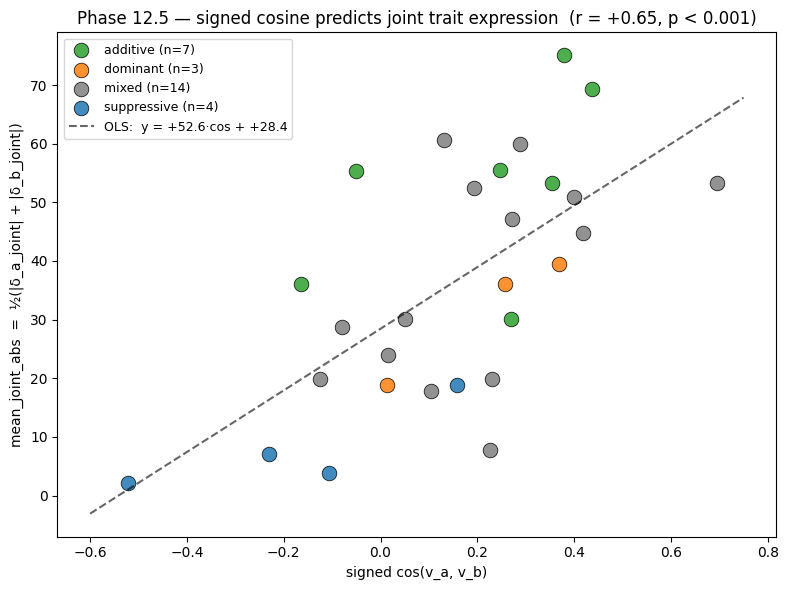

In [23]:
palette = {"additive":"tab:green","mixed":"tab:gray","dominant":"tab:orange",
           "suppressive":"tab:blue","emergent":"tab:red"}

# Main scatter: cos vs mean_joint_abs
fig, ax = plt.subplots(figsize=(8, 6))
for regime, sub in p125.groupby("regime"):
    ax.scatter(sub["cos"], sub["mean_joint_abs"], s=110, color=palette.get(regime,"k"),
               label=f"{regime} (n={len(sub)})", edgecolor="black", linewidth=0.6, alpha=0.85)
xs = np.linspace(-0.6, 0.75, 100)
slope, intercept = np.polyfit(p125["cos"], p125["mean_joint_abs"], 1)
ax.plot(xs, slope*xs + intercept, "k--", alpha=0.6, lw=1.5,
        label=f"OLS:  y = {slope:+.1f}·cos + {intercept:+.1f}")
ax.set_xlabel("signed cos(v_a, v_b)")
ax.set_ylabel("mean_joint_abs  =  ½(|δ_a_joint| + |δ_b_joint|)")
ax.set_title(f"Phase 12.5 — signed cosine predicts joint trait expression  (r = {r_obs:+.2f}, p < 0.001)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()


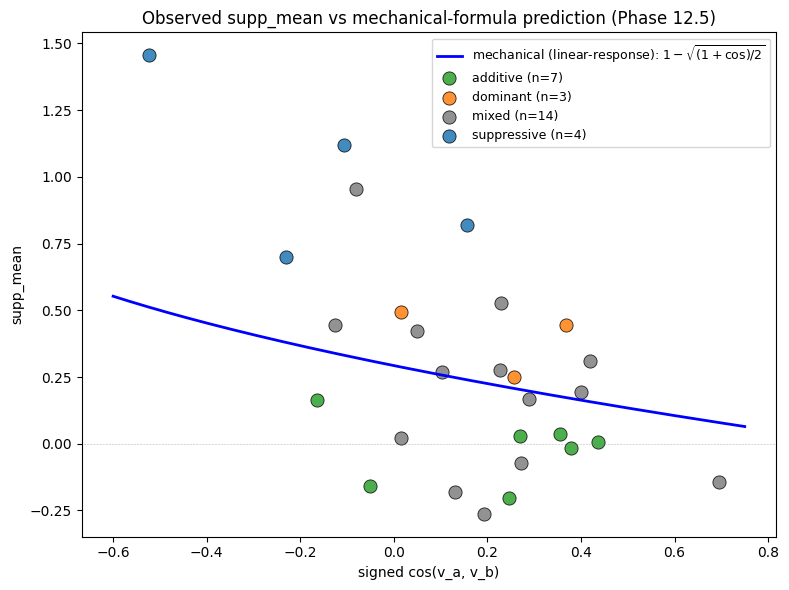

In [24]:
# Mechanical-vs-observed (for supp_mean, since that's where the formula applies cleanly)
fig, ax = plt.subplots(figsize=(8, 6))
xs = np.linspace(-0.6, 0.75, 200)
ys_mech = 1 - np.sqrt(np.clip((1+xs)/2, 0, None))
ax.plot(xs, ys_mech, "b-", lw=2, label=r"mechanical (linear-response): $1 - \sqrt{(1+\cos)/2}$")
for regime, sub in p125.groupby("regime"):
    ax.scatter(sub["cos"], sub["supp_mean"], s=90, color=palette.get(regime,"k"),
               label=f"{regime} (n={len(sub)})", edgecolor="black", linewidth=0.6, alpha=0.85)
ax.axhline(0, color="grey", lw=0.4, ls=":")
ax.set_xlabel("signed cos(v_a, v_b)")
ax.set_ylabel("supp_mean")
ax.set_title("Observed supp_mean vs mechanical-formula prediction (Phase 12.5)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()


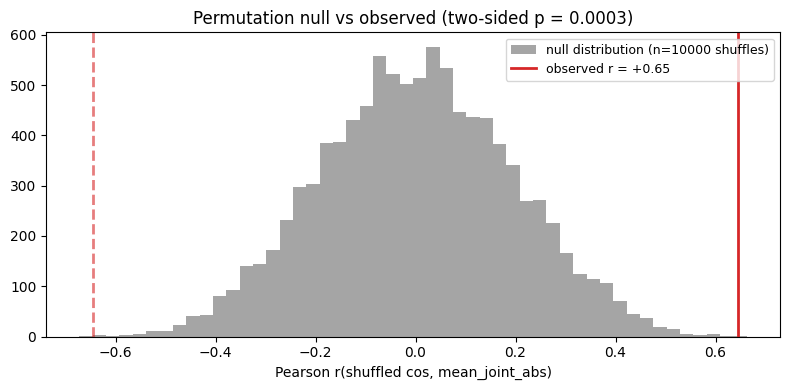

In [25]:
# Permutation null
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm, bins=50, color="tab:gray", alpha=0.7,
        label=f"null distribution (n={N_PERM} shuffles)")
ax.axvline(r_obs,  color="tab:red", lw=2, label=f"observed r = {r_obs:+.2f}")
ax.axvline(-r_obs, color="tab:red", lw=2, ls="--", alpha=0.6)
ax.set_xlabel("Pearson r(shuffled cos, mean_joint_abs)")
ax.set_title(f"Permutation null vs observed (two-sided p = {p_perm:.4f})")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 11. Take-aways — honest version

### What we can say with confidence

1. **Signed cos predicts joint trait expression** with effect size
   r ≈ +0.65 on `mean_joint_abs`, robust to alternative response measures,
   leave-one-pair-out, Bonferroni correction, ratio-reliability filtering,
   non-parametric tests, and cross-dataset replication (joint deltas
   r ≈ 0.92 between Phase 12 and Phase 12.5).
2. **Aligned vectors (positive cos) produce larger joint trait expression**
   in absolute terms; antipodal vectors (negative cos) produce smaller
   expression and frequent mutual suppression.
3. **The categorical regime classifier discards directional information.**
   `|cos|` and discrete `is_additive` produce null results; signed cos
   and continuous responses produce signal.
4. **Per-trait heterogeneity is real.** ANOVA on residuals of suppression
   after controlling for single-trait magnitude is significant
   (F = 4.02, p = 0.0016). Apathetic is the strongest individual signal
   (p = 0.007) but just misses Bonferroni correction across 8 traits
   (threshold 0.0063); read as a robust trend, not a single-trait finding.

### What we explicitly cannot say (yet)

1. **We cannot cleanly separate "geometry per se" from "design of the
   injection scheme".** The relationship between cos and per-axis push under
   `normalize=True` is partially mechanical (linear-response assumption
   predicts ~21% of supp_mean variance). The `composition_scoring_v3.py`
   per_axis run, which holds per-axis push constant, is needed to break
   this entanglement.
2. **We cannot make strong individual-trait dominance claims.**
   No single trait survives Bonferroni correction across 8 traits.
   Apathetic and hallucinating show the right direction (less suppressed
   than partners) but should be reported as trends, not findings.
3. **The "content vs stylistic" taxonomy of traits is post-hoc speculation**,
   not a tested hypothesis. It may motivate follow-up but is not a finding.
4. **The supp_mean correlation (r = −0.62) is inflated by ratio
   instability** in low-`|δ_single|` pairs (mostly formality-containing).
   Restricting to reliable ratios brings r to −0.32 (n.s.). The
   mean_joint_abs version is the defensible quantitative form.
5. **n = 28 is small.** All claims should be understood as initial
   characterization with substantial uncertainty intervals.

### Open questions for follow-up

- Does the `cos → mean_joint_abs` relationship survive under per_axis
  normalization (constant per-axis push)? **In progress** — cluster job 499694.
- What governs per-trait variation in dominance? Is it semantic content,
  rubric overlap, baseline saturation? **Untested.**
- Do these findings generalize to other layers (we've tested only L=17),
  models, and trait sets?